# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ Hamiltonians

Created: 13-06-2026

Objectives:
Create Hamiltoniains for $G_f = \mathbb{Z}_2^F \times \mathbb{Z}_2^T$ with $(n_1, \nu_2)=$
* (0, 1)
* (1, 1)
* (1,-1)
and interpolate through the three fixed point hamiltonians above.

# Imports

In [1]:
from time import time

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from itertools import product

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from humanize import naturalsize

# Test

In [9]:
L = 8

In [10]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [11]:
static = [
    ["|I", [[-1, i] for i in range(L)]],
    ["|n", [[1, i] for i in range(L)]],
    ["y|", [[-1, i] for i in range(L)]],
]

In [12]:
triv_hamiltonian = hamiltonian(
    static,
    [],
    basis=basis,
    dtype=np.complex128,
    check_symm=True,
    check_herm=True
)

Hermiticity check passed!


/tmp/ipykernel_17093/2111674603.py:1: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  triv_hamiltonian = hamiltonian(
/tmp/ipykernel_17093/2111674603.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  triv_hamiltonian = hamiltonian(


In [13]:
e, psi = triv_hamiltonian.eigsh(k=1, which='SA')

In [14]:
e

array([-16.])

In [15]:
y_up_eig_vec = (1/np.sqrt(2))*np.array([1, 1j])
y_down_eig_vec = (1/np.sqrt(2))*np.array([1, -1j])

y_eig_vecs = [
    y_up_eig_vec,
    y_down_eig_vec
]

In [16]:
np.outer(y_up_eig_vec, y_up_eig_vec.conj())

array([[0.5+0.j , 0. -0.5j],
       [0. +0.5j, 0.5+0.j ]])

In [17]:
np.outer(y_down_eig_vec, y_down_eig_vec.conj())

array([[0.5+0.j , 0. +0.5j],
       [0. -0.5j, 0.5+0.j ]])

In [18]:
np.outer(y_up_eig_vec, y_down_eig_vec.conj())

array([[ 0.5+0.j ,  0. +0.5j],
       [ 0. +0.5j, -0.5+0.j ]])

In [20]:
np.outer(y_down_eig_vec, y_up_eig_vec.conj())

array([[ 0.5+0.j ,  0. -0.5j],
       [ 0. -0.5j, -0.5-0.j ]])

In [21]:
X = np.outer(y_up_eig_vec, y_down_eig_vec.conj())

In [23]:
X @ X

array([[0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j]])

In [24]:
X = np.outer(y_down_eig_vec, y_up_eig_vec.conj())

In [25]:
X @ X

array([[0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j]])

In [133]:
spin_ops_dict = {
    (0,0): [("I", 1), ("y", 1)],
    (1,1): [("I", 1), ("y", -1)],
    (0,1): [("z", 1), ("x", 1j)],
    (1,0): [("z", 1), ("x", -1j)]
}

In [136]:
def get_fermionic_op_string(group_quad):
    g_left, g_in, g_out, g_right = group_quad

    out_string = ''
    out_indices = list()

    if (g_left + g_out) % 2:
        out_string += '+'
        out_indices.append(0)
    if (g_out + g_right) % 2:
        out_string += '+'
        out_indices.append(1)
    if (g_in + g_right) % 2:
        out_string += '-'
        out_indices.append(1)
    if (g_left + g_in) % 2:
        out_string += '-'
        out_indices.append(0)

    return (out_string, out_indices)

In [186]:
def get_group_quad_terms(group_quad, L):
    g_left, g_in, g_out, g_right = group_quad

    left_op = spin_ops_dict[(g_left, g_left)]
    mid_op = spin_ops_dict[(g_out, g_in)]
    right_op = spin_ops_dict[(g_right, g_right)]

    op_triples = product(left_op, mid_op, right_op)

    terms = list()

    for left_pair, mid_pair, right_pair in op_triples:
        left_string, left_strength = left_pair
        mid_string, mid_strength = mid_pair
        right_string, right_strength = right_pair

        spin_string = f"{left_string}{mid_string}{right_string}"
        strength = -(1/16)*left_strength*mid_strength*right_strength

        ferm_op_string, ferm_indices = get_fermionic_op_string(group_quad)
        op_string = f"{spin_string}|{ferm_op_string}"


        base_index = [0, 1, 2, *ferm_indices]
        all_indices = [
            [(x+i)%L for x in base_index]
            for i in range(L)
        ]

        current_term = [
            op_string, [[strength, *indices] for indices in all_indices]
        ]

        terms.append(current_term)

    return terms

In [145]:
L = 4

In [146]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [147]:
all_non_triv_terms = [
    l for group_quad in group_quads
    for l in get_group_quad_terms(group_quad, L)
]

In [148]:
non_triv_hamiltonian = hamiltonian(
    all_non_triv_terms,
    [],
    basis=basis,
    dtype=np.complex128,
    check_symm=False,
    check_herm=False
)

/tmp/ipykernel_11947/2547644671.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  non_triv_hamiltonian = hamiltonian(


In [149]:
A = non_triv_hamiltonian.toarray()

In [150]:
np.linalg.norm(A - A.conj().T)

np.float64(0.0)

So yes, it's Hermitian. Phew!

In [187]:
L = 4

In [188]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [189]:
all_non_triv_terms = [
    l for group_quad in group_quads
    for l in get_group_quad_terms(group_quad, L)
]

In [190]:
non_triv_hamiltonian = hamiltonian(
    all_non_triv_terms,
    [],
    basis=basis,
    dtype=np.complex128,
    check_symm=False,
    check_herm=False
)

/tmp/ipykernel_11947/2547644671.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  non_triv_hamiltonian = hamiltonian(


In [191]:
e, psi = non_triv_hamiltonian.eigsh(k=1, which='SA')

In [192]:
e

array([-4.])

In [193]:
np.sum(psi* psi.conj())

np.complex128(1+4.441740556709384e-18j)

In [181]:
all_non_triv_terms = [
    l for group_quad in group_quads
    for l in get_spin_group_quad_terms(group_quad, L)
]

In [182]:
non_triv_hamiltonian = hamiltonian(
    all_non_triv_terms,
    [],
    basis=basis,
    dtype=np.complex128,
    check_symm=False,
    check_herm=False
)

/tmp/ipykernel_11947/2547644671.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  non_triv_hamiltonian = hamiltonian(


In [183]:
np.linalg.norm(A - A.conj().T)

np.float64(0.0)

In [184]:
e, psi = non_triv_hamiltonian.eigsh(k=1, which='SA')

In [185]:
e

array([-4.])

In [194]:
def cocycle_phase(group_quad):
    g_left, g_in, g_out, g_right = group_quad

    exponent = (
        (g_in - g_left)*(g_right - g_in)
        - (g_out - g_left)*(g_right - g_out)
    )
    exponent = exponent % 2

    # i.e. (-1)**exponent
    out = -1 if exponent else 1

    return out

In [196]:
def get_phase_group_quad_terms(group_quad, L):
    g_left, g_in, g_out, g_right = group_quad

    left_op = spin_ops_dict[(g_left, g_left)]
    mid_op = spin_ops_dict[(g_out, g_in)]
    right_op = spin_ops_dict[(g_right, g_right)]

    op_triples = product(left_op, mid_op, right_op)

    terms = list()

    for left_pair, mid_pair, right_pair in op_triples:
        left_string, left_strength = left_pair
        mid_string, mid_strength = mid_pair
        right_string, right_strength = right_pair

        spin_string = f"{left_string}{mid_string}{right_string}"
        strength = -(1/16)*left_strength*mid_strength*right_strength

        ferm_op_string, ferm_indices = get_fermionic_op_string(group_quad)
        op_string = f"{spin_string}|{ferm_op_string}"


        base_index = [0, 1, 2, *ferm_indices]
        all_indices = [
            [(x+i)%L for x in base_index]
            for i in range(L)
        ]

        phase = cocycle_phase(group_quad)
        
        current_term = [
            op_string, [[phase*strength, *indices] for indices in all_indices]
        ]

        terms.append(current_term)

    return terms

In [203]:
all_non_triv_terms = [
    l for group_quad in group_quads
    for l in get_phase_group_quad_terms(group_quad, L)
]

In [204]:
non_triv_hamiltonian = hamiltonian(
    all_non_triv_terms,
    [],
    basis=basis,
    dtype=np.complex128,
    check_symm=False,
    check_herm=False
)

/tmp/ipykernel_11947/2547644671.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  non_triv_hamiltonian = hamiltonian(


In [205]:
A = non_triv_hamiltonian.toarray()

In [206]:
np.linalg.norm(A - A.conj().T)

np.float64(0.0)

In [207]:
e, psi = non_triv_hamiltonian.eigsh(k=1, which='SA')

In [208]:
e

array([-4.])

In [209]:
[
    cocycle_phase(group_quad)
    for group_quad in group_quads
]

[1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, 1, -1, 1, 1]

All working! Now interpolate, figure out how large we can push this.

## Interpolated hamiltonians

In [246]:
def get_nontrivial_fermionic_op_string(group_quad):
    g_left, g_in, g_out, g_right = group_quad

    out_string = ''
    out_indices = list()

    if (g_left + g_out) % 2:
        out_string += '+'
        out_indices.append(0)
    if (g_out + g_right) % 2:
        out_string += '+'
        out_indices.append(1)
    if (g_in + g_right) % 2:
        out_string += '-'
        out_indices.append(1)
    if (g_left + g_in) % 2:
        out_string += '-'
        out_indices.append(0)

    return (out_string, out_indices)

In [247]:
def get_fermionic_op_string(group_quad, fermionic_decoration):
    if fermionic_decoration:
        return get_nontrivial_fermionic_op_string(group_quad)
    else:
        return ('', [])

In [272]:
def get_group_quad_terms(group_quad, L, fermionic_decoration=False,
                         nontriv_cocycle=False, strength_scaling=1):
    g_left, g_in, g_out, g_right = group_quad

    left_op = spin_ops_dict[(g_left, g_left)]
    mid_op = spin_ops_dict[(g_out, g_in)]
    right_op = spin_ops_dict[(g_right, g_right)]

    op_triples = product(left_op, mid_op, right_op)

    terms = list()

    for left_pair, mid_pair, right_pair in op_triples:
        left_string, left_strength = left_pair
        mid_string, mid_strength = mid_pair
        right_string, right_strength = right_pair

        spin_string = f"{left_string}{mid_string}{right_string}"
        strength = -(1/16)*left_strength*mid_strength*right_strength

        ferm_op_string, ferm_indices = get_fermionic_op_string(
            group_quad,
            fermionic_decoration
        )
        op_string = f"{spin_string}|{ferm_op_string}"

        base_index = [0, 1, 2, *ferm_indices]
        all_indices = [
            [(x+i)%L for x in base_index]
            for i in range(L)
        ]

        phase = cocycle_phase(group_quad) if nontriv_cocycle else 1
        scaling_constant = strength*strength_scaling*phase
        current_term = [
            op_string, [[scaling_constant, *indices] for indices in all_indices]
        ]

        terms.append(current_term)

    return terms

In [273]:
def get_triv_to_n1_non_triv_hamiltonian(t, L):
    spin_basis = spin_basis_1d(L)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    triv_terms = [
        l for group_quad in group_quads
        for l in get_group_quad_terms(group_quad, L, False, False, 1-t)
    ]

    non_triv_terms = [
        l for group_quad in group_quads
        for l in get_group_quad_terms(group_quad, L, True, False, t)
    ]

    all_terms = triv_terms + non_triv_terms

    h = hamiltonian(
        all_terms,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return h

In [264]:
parameters = np.linspace(0, 1, 11)

In [265]:
L=8

In [267]:
hamiltonians = [
    get_triv_to_n1_non_triv_hamiltonian(t, L)
    for t in parameters
]

/tmp/ipykernel_11947/2246995478.py:18: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(


In [269]:
energies = [
    h.eigsh(k=1, which='SA')[0]
    for h in hamiltonians
]

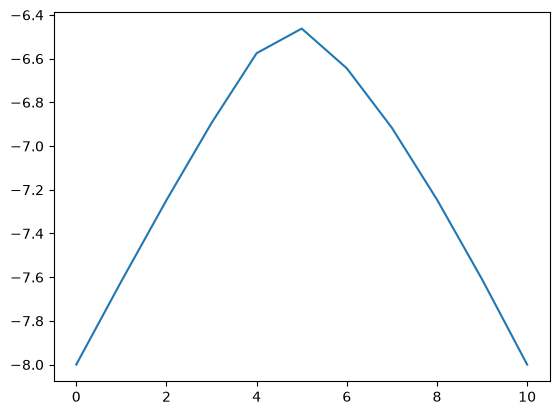

In [270]:
plt.plot(energies)

In [271]:
energies

[array([-8.]),
 array([-7.6184843]),
 array([-7.24767821]),
 array([-6.89451528]),
 array([-6.57510346]),
 array([-6.46252853]),
 array([-6.64429883]),
 array([-6.91661808]),
 array([-7.24511861]),
 array([-7.61000515]),
 array([-8.])]

In [280]:
def get_nontriv_n1_to_nontriv_cocycle_hamiltonian(t, L):
    spin_basis = spin_basis_1d(L)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    triv_terms = [
        l for group_quad in group_quads
        for l in get_group_quad_terms(group_quad, L, True, False, 1-t)
    ]

    non_triv_terms = [
        l for group_quad in group_quads
        for l in get_group_quad_terms(group_quad, L, True, True, t)
    ]

    all_terms = triv_terms + non_triv_terms

    h = hamiltonian(
        all_terms,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return h

In [281]:
parameters = np.linspace(0, 1, 11)

In [282]:
L=8

In [283]:
hamiltonians = [
    get_nontriv_n1_to_nontriv_cocycle_hamiltonian(t, L)
    for t in parameters
]

/tmp/ipykernel_11947/1466521248.py:18: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(


In [284]:
energies = [
    h.eigsh(k=1, which='SA')[0]
    for h in hamiltonians
]

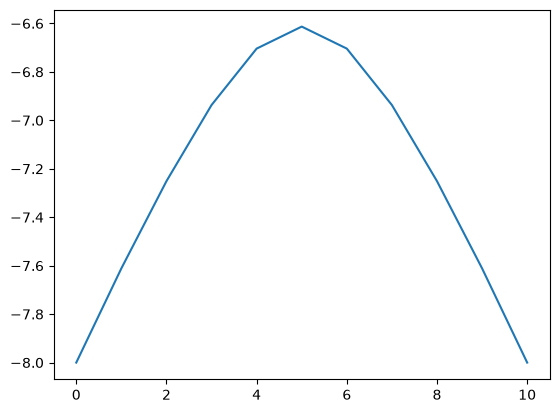

In [285]:
plt.plot(energies)

In [286]:
energies

[array([-8.]),
 array([-7.61116239]),
 array([-7.25115214]),
 array([-6.93693275]),
 array([-6.70400342]),
 array([-6.61312593]),
 array([-6.70400342]),
 array([-6.93693275]),
 array([-7.25115214]),
 array([-7.61116239]),
 array([-8.])]

## Check scaling

In [304]:
t=0.7

sizes = list(range(1, 14))
memories = list()
hamiltonian_times = list()
grounstate_times = list()

for L in sizes:
    print(L)
    t1 = time()
    h = get_triv_to_n1_non_triv_hamiltonian(0.7, L)
    t2 = time()
    e, psi = h.eigsh(k=1, which='SA')
    t3 = time()

    memories.append(psi.nbytes)
    hamiltonian_times.append(t2-t1)
    grounstate_times.append(t3-t2)

1
2
3
4
5


/tmp/ipykernel_11947/2504458043.py:18: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(


6
7
8
9
10
11
12


KeyboardInterrupt: 

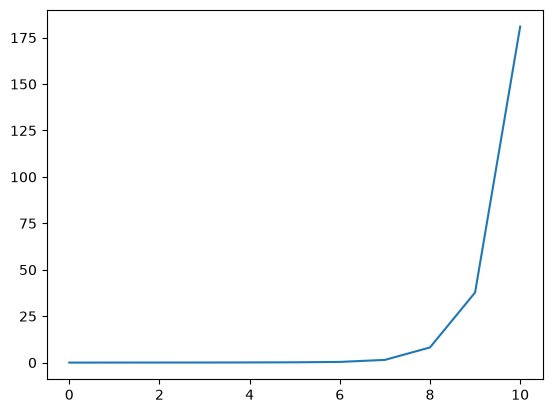

In [305]:
plt.plot(hamiltonian_times)

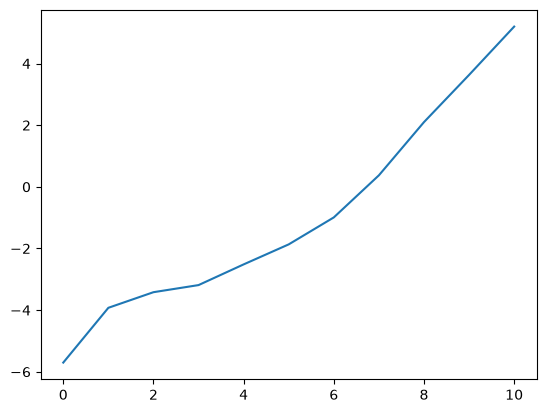

In [306]:
plt.plot(np.log(np.array(hamiltonian_times)))

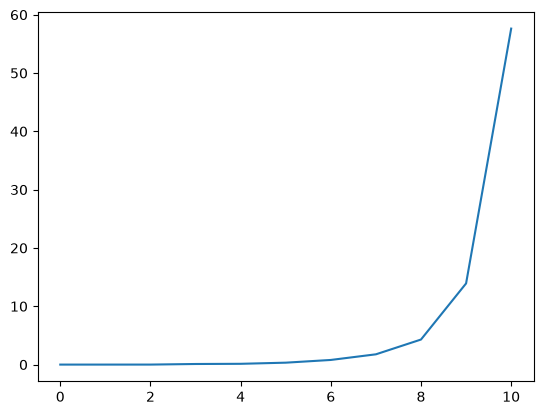

In [307]:
plt.plot(grounstate_times)

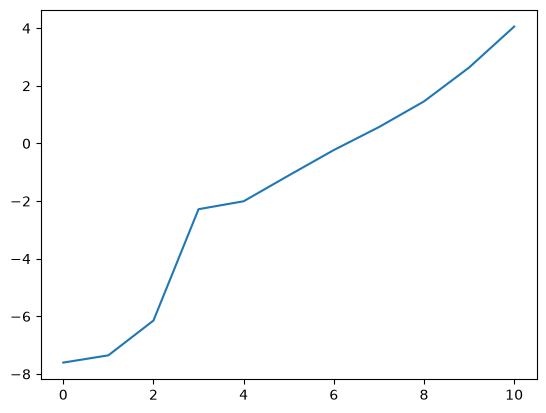

In [308]:
plt.plot(np.log(np.array(grounstate_times)))

In [309]:
total_times = np.array(grounstate_times) + np.array(hamiltonian_times)

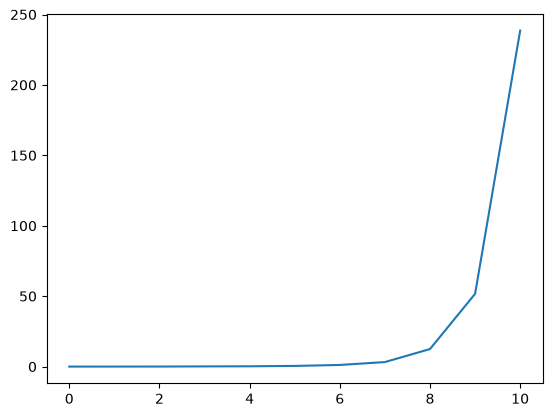

In [310]:
plt.plot(total_times)

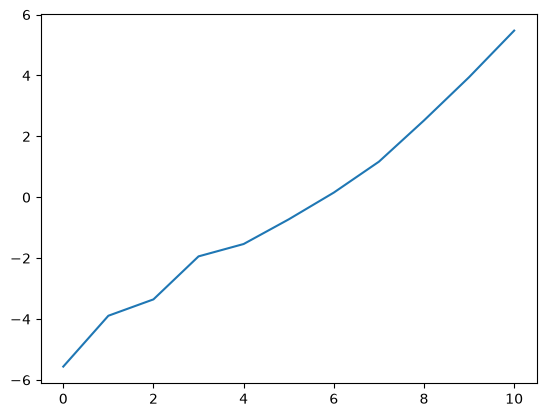

In [311]:
plt.plot(np.log(total_times))

In [312]:
total_times

array([3.83782387e-03, 2.03883648e-02, 3.49090099e-02, 1.43358946e-01,
       2.15147257e-01, 4.83826399e-01, 1.16578984e+00, 3.21525455e+00,
       1.24638221e+01, 5.16687644e+01, 2.38582250e+02])

In [313]:
total_times[1:]/total_times[:-1]

array([5.31248059, 1.71220254, 4.106646  , 1.5007592 , 2.24881509,
       2.40952095, 2.75800528, 3.87646513, 4.14549918, 4.6175335 ])

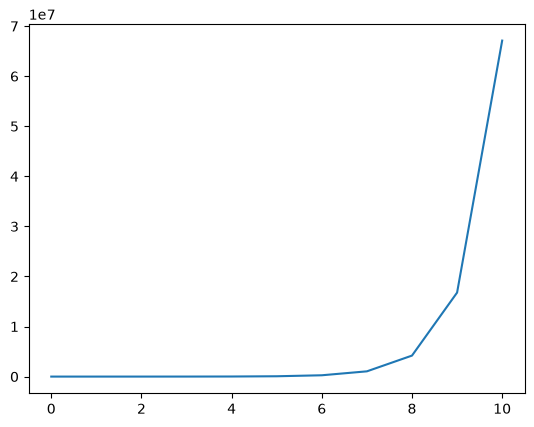

In [314]:
plt.plot(memories)

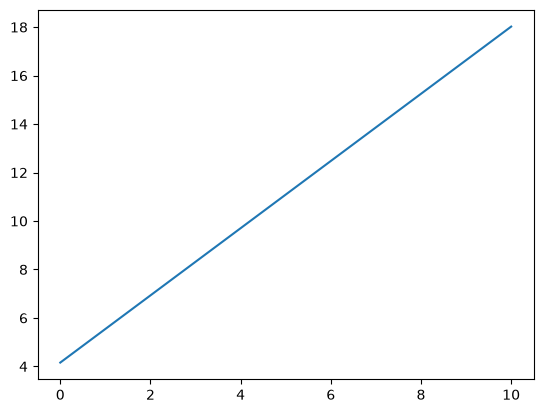

In [315]:
plt.plot(np.log(np.array(memories)))

In [316]:
(
    naturalsize(memories[-3]),
    naturalsize(memories[-2]),
    naturalsize(memories[-1])
)

('4.2 MB', '16.8 MB', '67.1 MB')

# Conclusion
Looks good! Sweep in another notebook.

# Old code

## Minimal not working example

In [109]:
def get_spin_group_quad_terms(group_quad, L):
    g_left, g_in, g_out, g_right = group_quad

    left_op = spin_ops_dict[(g_left, g_left)]
    mid_op = spin_ops_dict[(g_out, g_in)]
    right_op = spin_ops_dict[(g_right, g_right)]

    op_triples = product(left_op, mid_op, right_op)

    terms = list()

    for left_pair, mid_pair, right_pair in op_triples:
        left_string, left_strength = left_pair
        mid_string, mid_strength = mid_pair
        right_string, right_strength = right_pair

        spin_string = f"{left_string}{mid_string}{right_string}"
        strength = (1/8)*left_strength*mid_strength*right_strength

        op_string = f"{spin_string}|"


        base_index = [0, 1, 2]
        all_indices = [
            [(x+i)%L for x in base_index]
            for i in range(L)
        ]

        current_term = [
            op_string, [[strength, *indices] for indices in all_indices]
        ]

        terms.append(current_term)

    return terms

In [110]:
def get_fermion_group_quad_terms(group_quad, L):
    g_left, g_in, g_out, g_right = group_quad

    left_op = spin_ops_dict[(g_left, g_left)]
    mid_op = spin_ops_dict[(g_out, g_in)]
    right_op = spin_ops_dict[(g_right, g_right)]

    op_triples = product(left_op, mid_op, right_op)

    terms = list()

    for left_pair, mid_pair, right_pair in op_triples:
        left_string, left_strength = left_pair
        mid_string, mid_strength = mid_pair
        right_string, right_strength = right_pair

        spin_string = f"{left_string}{mid_string}{right_string}"
        strength = (1/8)

        ferm_op_string, ferm_indices = get_fermionic_op_string(group_quad)
        op_string = f"|{ferm_op_string}"

        base_index = [*ferm_indices]
        all_indices = [
            [(x+i)%L for x in base_index]
            for i in range(L)
        ]

        current_term = [
            op_string, [[strength, *indices] for indices in all_indices]
        ]

        terms.append(current_term)

    return terms

In [114]:
L = 3

In [115]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [116]:
all_non_triv_terms = [
    l for group_quad in group_quads
    for l in get_fermion_group_quad_terms(group_quad, L)
]

In [117]:
all_non_triv_terms

[['|', [[0.125], [0.125], [0.125]]],
 ['|', [[0.125], [0.125], [0.125]]],
 ['|', [[0.125], [0.125], [0.125]]],
 ['|', [[0.125], [0.125], [0.125]]],
 ['|', [[0.125], [0.125], [0.125]]],
 ['|', [[0.125], [0.125], [0.125]]],
 ['|', [[0.125], [0.125], [0.125]]],
 ['|', [[0.125], [0.125], [0.125]]],
 ['|+-', [[0.125, 1, 1], [0.125, 2, 2], [0.125, 0, 0]]],
 ['|+-', [[0.125, 1, 1], [0.125, 2, 2], [0.125, 0, 0]]],
 ['|+-', [[0.125, 1, 1], [0.125, 2, 2], [0.125, 0, 0]]],
 ['|+-', [[0.125, 1, 1], [0.125, 2, 2], [0.125, 0, 0]]],
 ['|+-', [[0.125, 1, 1], [0.125, 2, 2], [0.125, 0, 0]]],
 ['|+-', [[0.125, 1, 1], [0.125, 2, 2], [0.125, 0, 0]]],
 ['|+-', [[0.125, 1, 1], [0.125, 2, 2], [0.125, 0, 0]]],
 ['|+-', [[0.125, 1, 1], [0.125, 2, 2], [0.125, 0, 0]]],
 ['|++', [[0.125, 0, 1], [0.125, 1, 2], [0.125, 2, 0]]],
 ['|++', [[0.125, 0, 1], [0.125, 1, 2], [0.125, 2, 0]]],
 ['|++', [[0.125, 0, 1], [0.125, 1, 2], [0.125, 2, 0]]],
 ['|++', [[0.125, 0, 1], [0.125, 1, 2], [0.125, 2, 0]]],
 ['|++', [[0.125, 0,

In [120]:
small_terms = [
    ['|--', [[0.125, 1, 0], [0.125, 2, 1], [0.125, 0, 2]]],
    ['|++', [[0.125, 0, 1], [0.125, 1, 2], [0.125, 2, 0]]]
]

In [121]:
non_triv_hamiltonian = hamiltonian(
    small_terms,
    [],
    basis=basis,
    dtype=np.complex128,
    check_symm=True,
    check_herm=True
)

/tmp/ipykernel_11947/2946708646.py:1: UserWarning: The following static operator strings contain non-hermitian couplings: ['|++', '|--']
  non_triv_hamiltonian = hamiltonian(


Display all 6 non-hermitian couplings? (y or n)  y


   (opstr, indices, coupling)
1. ('|--', (0, 1), (0.125+0j))
2. ('|++', (1, 2), (0.125+0j))
3. ('|++', (0, 2), (0.125+0j))
4. ('|--', (1, 2), (0.125+0j))
5. ('|++', (0, 1), (0.125+0j))
6. ('|--', (0, 2), (0.125+0j))


TypeError: Hamiltonian not hermitian! To turn this check off set check_herm=False in hamiltonian.